In [3]:
import requests
import pandas as pd

# call the API
response = requests.get('http://127.0.0.1:5000/api/campaigns?days=90')

# check status
print(f"Status code: {response.status_code}")
print(f"Status: {response.json()['status']}")
print(f"Total records: {response.json()['total_records']}")

# convert to dataframe
data = response.json()['data']
df = pd.DataFrame(data)

print(df.shape)
print(df.head())

Status code: 200
Status: success
Total records: 2700
(2700, 12)
          campaign     channel  clicks  conversion_rate  conversions   ctr  \
0      Summer Sale  Google Ads     763             3.97           30  1.78   
1       New Launch  Google Ads    2804             3.18           89  6.18   
2      Retargeting  Google Ads     402             3.41           13  2.63   
3  Brand Awareness  Google Ads     724             3.36           24  2.54   
4    Festive Offer  Google Ads    1850             2.11           39  3.96   

         date  impressions         region    revenue   roas    spend  
0  2024-01-01        42905    North India   33837.62  11.97  2826.47  
1  2024-01-01        45348    North India   57228.96   9.37  6109.68  
2  2024-01-01        15328  Central India   48387.15   8.30  5831.83  
3  2024-01-01        28493    South India   12701.87   1.55  8189.59  
4  2024-01-01        46753    North India  153493.22  60.30  2545.48  


In [5]:
print(f"Total rows: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Channels: {df['channel'].unique()}")
print(f"Campaigns: {df['campaign'].unique()}")
print(f"Regions: {df['region'].unique()}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nTotal spend: ₹{df['spend'].sum():,.2f}")
print(f"Total revenue: ₹{df['revenue'].sum():,.2f}")
print(f"Overall ROAS: {df['revenue'].sum() / df['spend'].sum():.2f}")

Total rows: 2700
Date range: 2024-01-01 to 2024-03-30
Channels: ['Google Ads' 'Facebook Ads' 'Email' 'Instagram' 'YouTube' 'SEO']
Campaigns: ['Summer Sale' 'New Launch' 'Retargeting' 'Brand Awareness'
 'Festive Offer']
Regions: ['North India' 'Central India' 'South India' 'West India' 'East India']

Missing values:
campaign           0
channel            0
clicks             0
conversion_rate    0
conversions        0
ctr                0
date               0
impressions        0
region             0
revenue            0
roas               0
spend              0
dtype: int64

Total spend: ₹14,106,031.11
Total revenue: ₹253,152,204.69
Overall ROAS: 17.95


In [7]:
# key metrics per channel
channel_metrics = df.groupby('channel').agg(
    total_spend       = ('spend', 'sum'),
    total_revenue     = ('revenue', 'sum'),
    total_clicks      = ('clicks', 'sum'),
    total_conversions = ('conversions', 'sum'),
    total_impressions = ('impressions', 'sum'),
    avg_ctr           = ('ctr', 'mean'),
    avg_conv_rate     = ('conversion_rate', 'mean')
).reset_index()

# calculate ROAS, CAC, ROI
channel_metrics['roas'] = (channel_metrics['total_revenue'] / channel_metrics['total_spend']).round(2)
channel_metrics['cac']  = (channel_metrics['total_spend'] / channel_metrics['total_conversions']).round(2)
channel_metrics['roi']  = ((channel_metrics['total_revenue'] - channel_metrics['total_spend']) / channel_metrics['total_spend'] * 100).round(2)

print(channel_metrics[['channel','total_spend','total_revenue','roas','cac','roi']].sort_values('roas', ascending=False).to_string())

        channel  total_spend  total_revenue   roas     cac      roi
0         Email   2350860.42    44746705.14  19.03  145.10  1803.42
3     Instagram   2246212.94    42161748.80  18.77  145.40  1777.01
2    Google Ads   2388627.70    43982948.17  18.41  149.01  1741.35
5       YouTube   2373540.43    42108064.85  17.74  156.25  1674.06
4           SEO   2339429.93    41450130.74  17.72  157.62  1671.80
1  Facebook Ads   2407359.69    38702606.99  16.08  164.07  1507.68


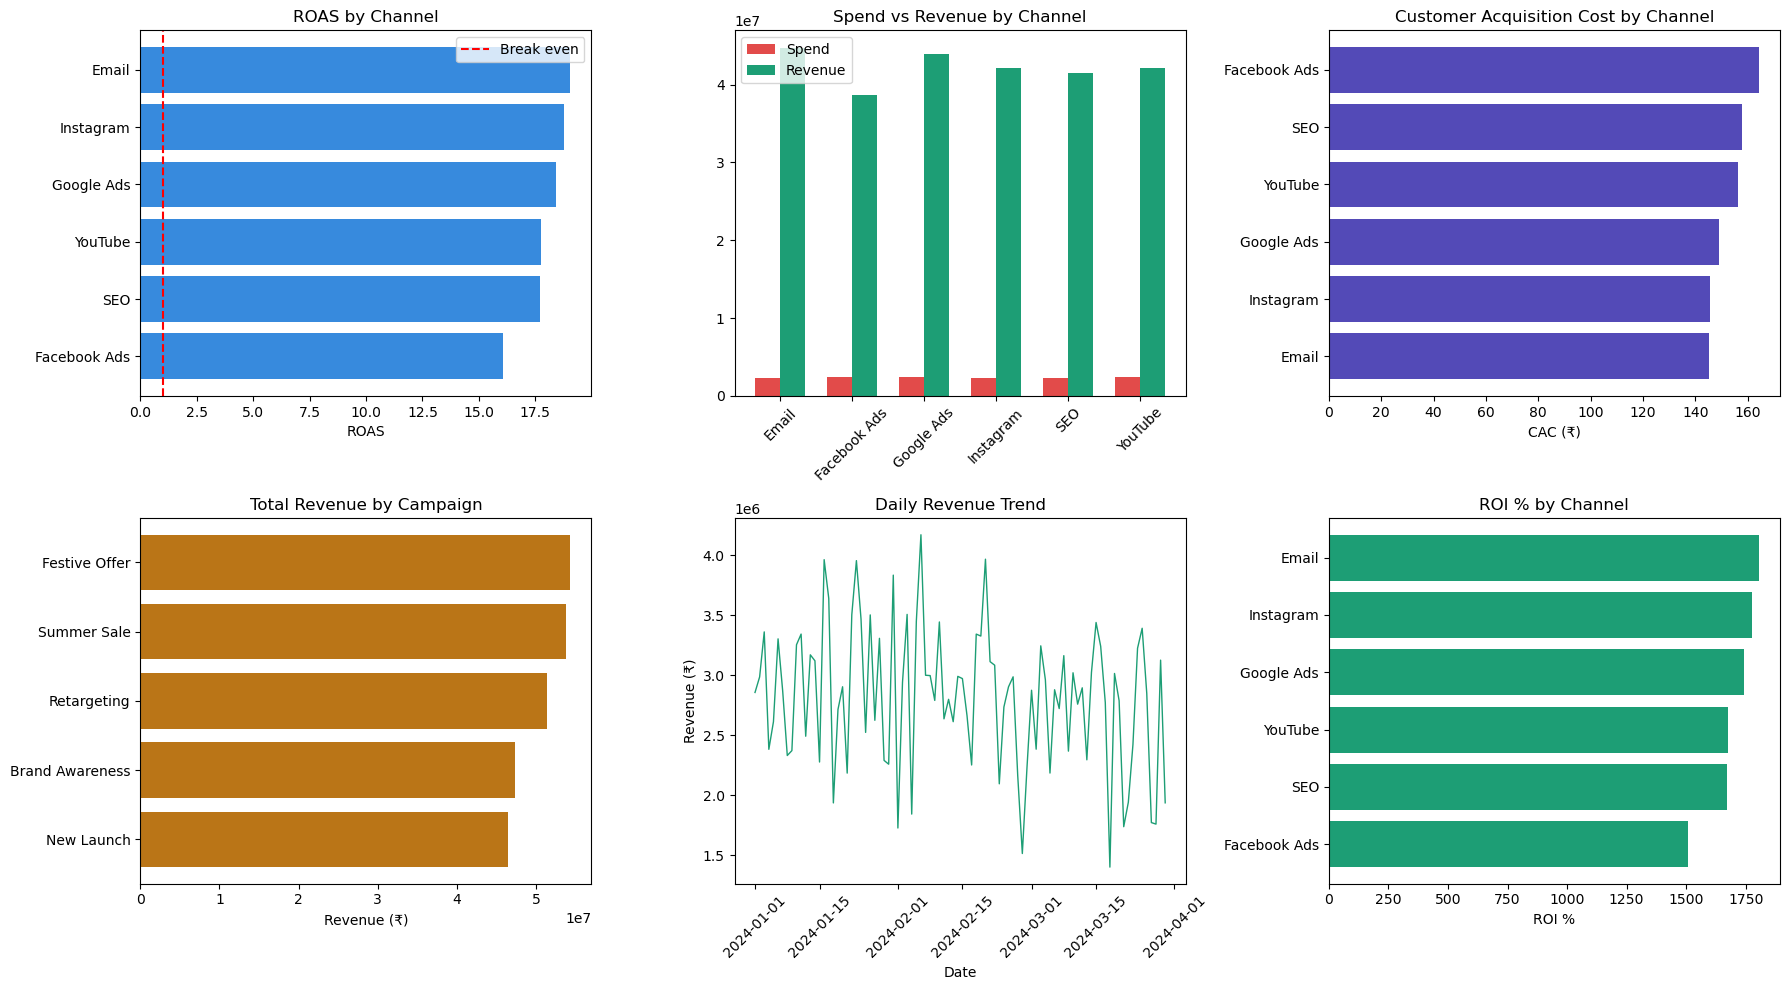

EDA plots saved.


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — ROAS by channel
channel_sorted = channel_metrics.sort_values('roas', ascending=True)
axes[0,0].barh(channel_sorted['channel'], channel_sorted['roas'], color='#378ADD')
axes[0,0].set_title('ROAS by Channel')
axes[0,0].set_xlabel('ROAS')
axes[0,0].axvline(x=1, color='red', linestyle='--', label='Break even')
axes[0,0].legend()

# Plot 2 — Spend vs Revenue
x = range(len(channel_metrics))
width = 0.35
axes[0,1].bar([i-width/2 for i in x], channel_metrics['total_spend'],
              width, label='Spend', color='#E24B4A')
axes[0,1].bar([i+width/2 for i in x], channel_metrics['total_revenue'],
              width, label='Revenue', color='#1D9E75')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(channel_metrics['channel'], rotation=45)
axes[0,1].set_title('Spend vs Revenue by Channel')
axes[0,1].legend()

# Plot 3 — CAC by channel
channel_sorted2 = channel_metrics.sort_values('cac', ascending=True)
axes[0,2].barh(channel_sorted2['channel'], channel_sorted2['cac'], color='#534AB7')
axes[0,2].set_title('Customer Acquisition Cost by Channel')
axes[0,2].set_xlabel('CAC (₹)')

# Plot 4 — Revenue by campaign
campaign_revenue = df.groupby('campaign')['revenue'].sum().sort_values(ascending=True)
axes[1,0].barh(campaign_revenue.index, campaign_revenue.values, color='#BA7517')
axes[1,0].set_title('Total Revenue by Campaign')
axes[1,0].set_xlabel('Revenue (₹)')

# Plot 5 — Daily revenue trend
df['date'] = pd.to_datetime(df['date'])
daily_revenue = df.groupby('date')['revenue'].sum()
axes[1,1].plot(daily_revenue.index, daily_revenue.values, color='#1D9E75', linewidth=1)
axes[1,1].set_title('Daily Revenue Trend')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Revenue (₹)')
axes[1,1].tick_params(axis='x', rotation=45)

# Plot 6 — ROI by channel
channel_sorted3 = channel_metrics.sort_values('roi', ascending=True)
colors = ['#E24B4A' if x < 0 else '#1D9E75' for x in channel_sorted3['roi']]
axes[1,2].barh(channel_sorted3['channel'], channel_sorted3['roi'], color=colors)
axes[1,2].set_title('ROI % by Channel')
axes[1,2].set_xlabel('ROI %')
axes[1,2].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(r'C:\Users\sahil\marketing_project\screenshots\01_eda_full.png', dpi=150)
plt.show()
print("EDA plots saved.")

In [13]:
from sqlalchemy import create_engine

engine = create_engine(
    'mssql+pyodbc://LAPTOP-RNCU5CQF\SQLEXPRESS/MarketingDB'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&trusted_connection=yes'
)

df.to_sql(
    name      = 'campaign_data',
    con       = engine,
    if_exists = 'replace',
    index     = False
)

print(f"Done. {len(df)} rows loaded to SQL Server.")

Done. 2700 rows loaded to SQL Server.
